In [1]:
import pandas as pd
import numpy as np
import os
data_path = './data/' 
from scipy import stats
import matplotlib.pyplot as plt
%matplotlib inline

# Import models
from pyod.models.abod import ABOD
from pyod.models.cblof import CBLOF
from pyod.models.feature_bagging import FeatureBagging
from pyod.models.hbos import HBOS
from pyod.models.iforest import IForest
from pyod.models.knn import KNN
from pyod.models.lof import LOF
# reading the big mart sales training data
df = pd.read_csv(os.path.join(data_path,'train_precleaned.csv'))
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Identifier_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,FD,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,DR,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,FD,2097.2700
3,FDX07,19.20,Regular,0.022960,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,FD,732.3800
4,NCD19,8.93,No Fat,0.016164,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,NC,994.7052


In [2]:
df_test=pd.read_csv(os.path.join(data_path,'test_precleaned.csv'))
df_test.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Identifier_Type
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1,FD
1,FDW14,8.300,Regular,0.038428,Dairy,87.3198,OUT017,2007,Small,Tier 2,Supermarket Type1,FD
2,NCN55,14.600,No Fat,0.099575,Others,241.7538,OUT010,1998,Small,Tier 3,Grocery Store,NC
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,Small,Tier 2,Supermarket Type1,FD
4,FDY38,13.600,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3,FD


<Axes: xlabel='Item_MRP', ylabel='Item_Outlet_Sales'>

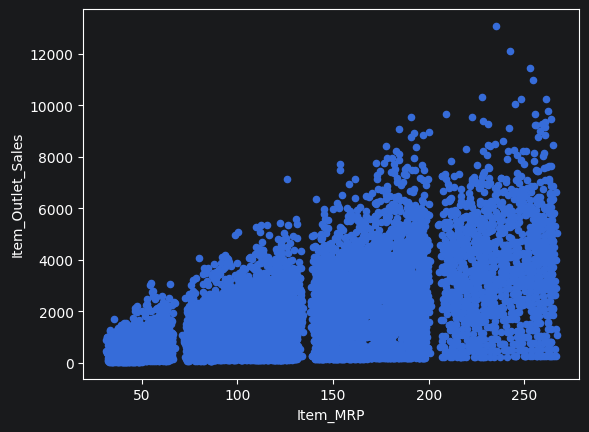

In [3]:
#Let’s plot Item MRP vs Item Outlet Sales to understand the data: 2-dimentional analysis

df.plot.scatter('Item_MRP','Item_Outlet_Sales')

In [3]:
from sklearn.preprocessing import MinMaxScaler

# FIX 1: Keep unscaled copies of MRP and Sales before transforming df.
# df_multi (created later) will use df.copy(), so without this it would inherit
# already-scaled values — making the raw-value display in the top-anomalies table
# meaningless and silently breaking any percentile-rank computation that expects
# original-scale data.
df['Item_MRP_raw']          = df['Item_MRP']
df['Item_Outlet_Sales_raw'] = df['Item_Outlet_Sales']

scaler = MinMaxScaler(feature_range=(0, 1))
df[['Item_MRP','Item_Outlet_Sales']] = scaler.fit_transform(df[['Item_MRP','Item_Outlet_Sales']])
df[['Item_MRP','Item_Outlet_Sales']].head()


,Item_MRP,Item_Outlet_Sales
0,0.927507,0.283587
1,0.072068,0.031419
2,0.468288,0.158115
3,0.640093,0.053555
4,0.095805,0.073651


In [4]:
X1 = df['Item_MRP'].values.reshape(-1,1)
X2 = df['Item_Outlet_Sales'].values.reshape(-1,1)

X = np.concatenate((X1,X2),axis=1)

PyOD has 40+ algorithms. These 7 were chosen because they
represent the 5 major families of anomaly detection, they
are computationally feasible on 8,523 rows, and they are
the most cited algorithms in the PyOD paper itself (Zhao
et al. 2019) — making this a standard benchmark selection,
not an arbitrary one

In [5]:
random_state = np.random.RandomState(42)
outliers_fraction = 0.05
# Define seven outlier detection tools to be compared
classifiers = {
        'Angle-based Outlier Detector (ABOD)': ABOD(contamination=outliers_fraction),
        'Cluster-based Local Outlier Factor (CBLOF)':CBLOF(contamination=outliers_fraction,check_estimator=False, random_state=random_state),
        'Feature Bagging':FeatureBagging(LOF(n_neighbors=35),contamination=outliers_fraction,check_estimator=False,random_state=random_state),
        'Histogram-base Outlier Detection (HBOS)': HBOS(contamination=outliers_fraction),
        'Isolation Forest': IForest(contamination=outliers_fraction,random_state=random_state),
        'K Nearest Neighbors (KNN)': KNN(contamination=outliers_fraction),
        'Average KNN': KNN(method='mean',contamination=outliers_fraction)
}

OUTLIERS : 427  INLIERS : 8096  Angle-based Outlier Detector (ABOD)


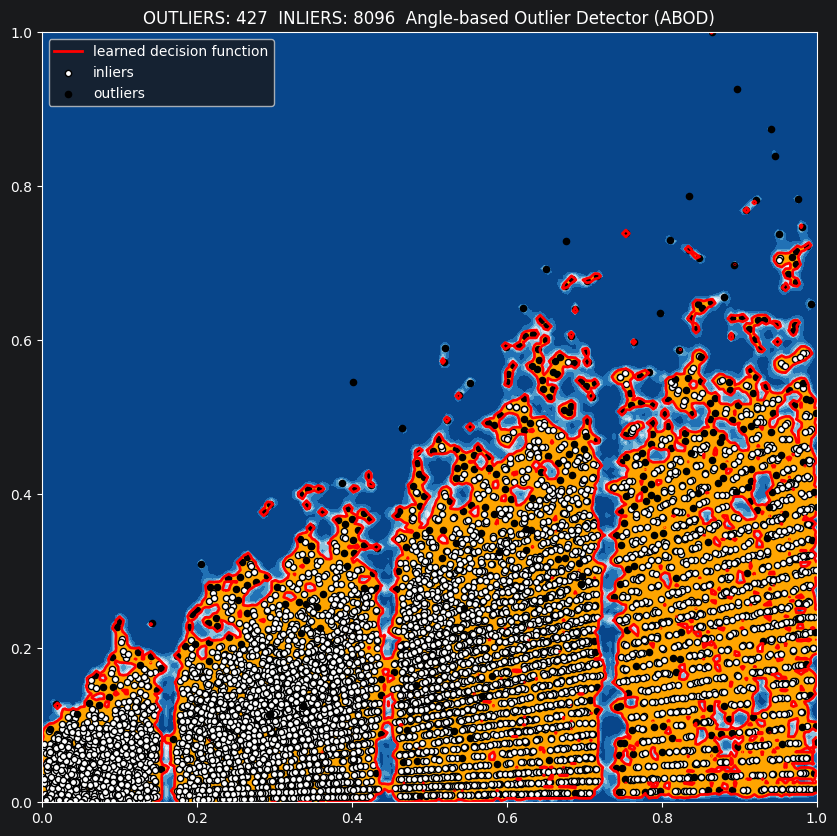

OUTLIERS : 427  INLIERS : 8096  Cluster-based Local Outlier Factor (CBLOF)


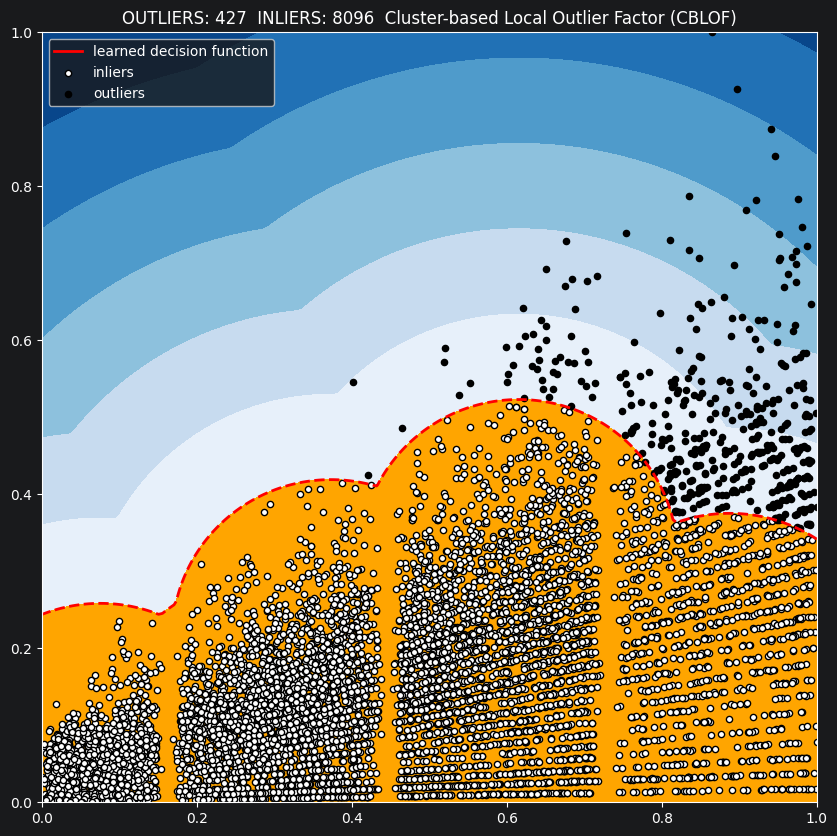

OUTLIERS : 369  INLIERS : 8154  Feature Bagging


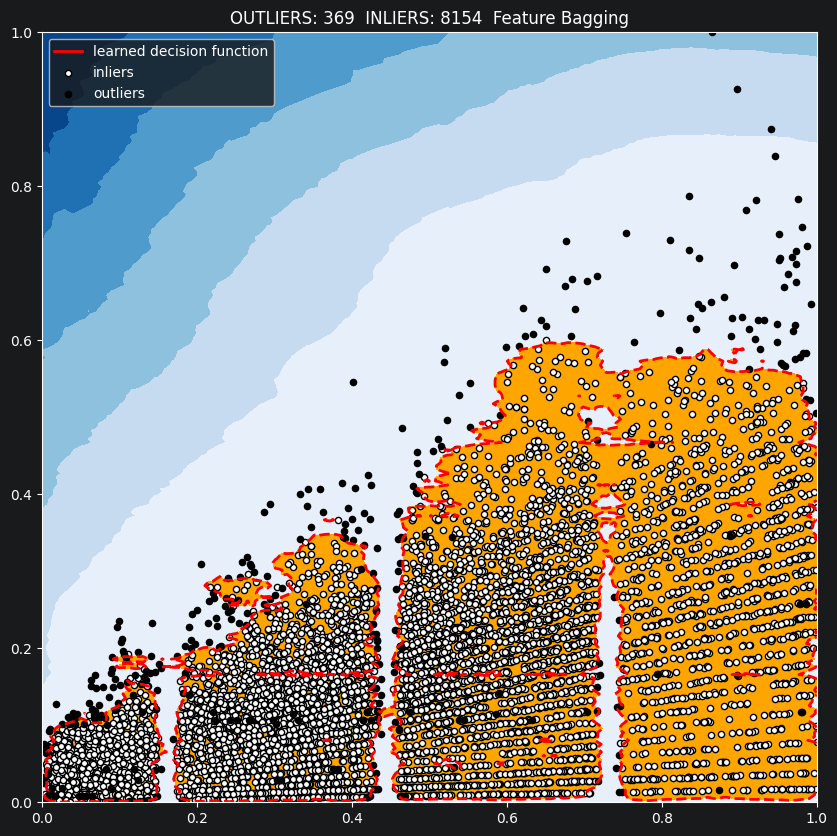

OUTLIERS : 418  INLIERS : 8105  Histogram-base Outlier Detection (HBOS)


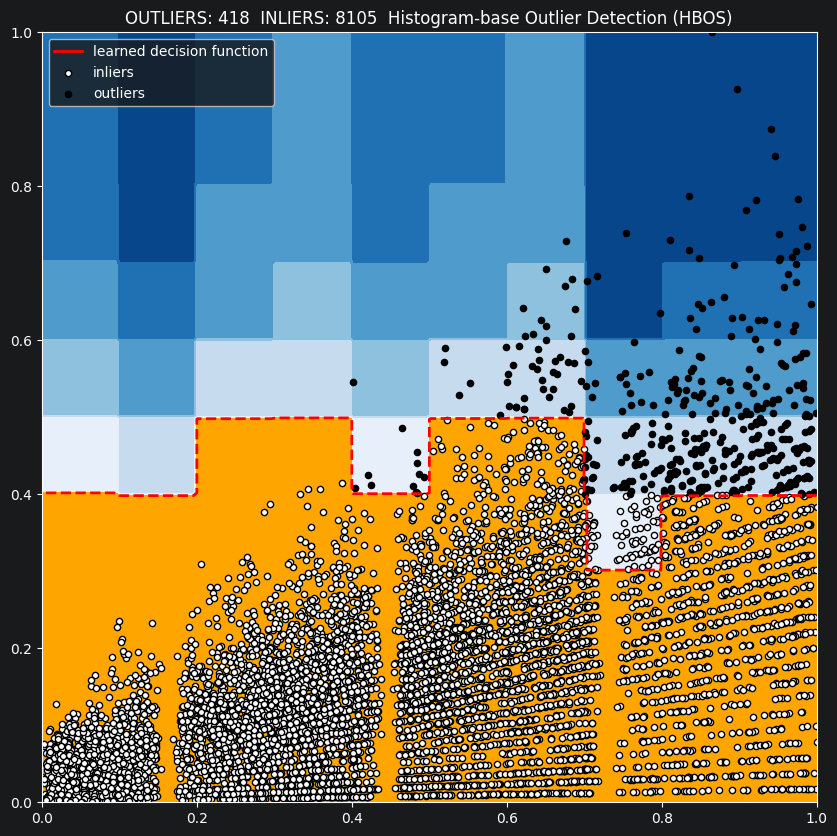

OUTLIERS : 427  INLIERS : 8096  Isolation Forest


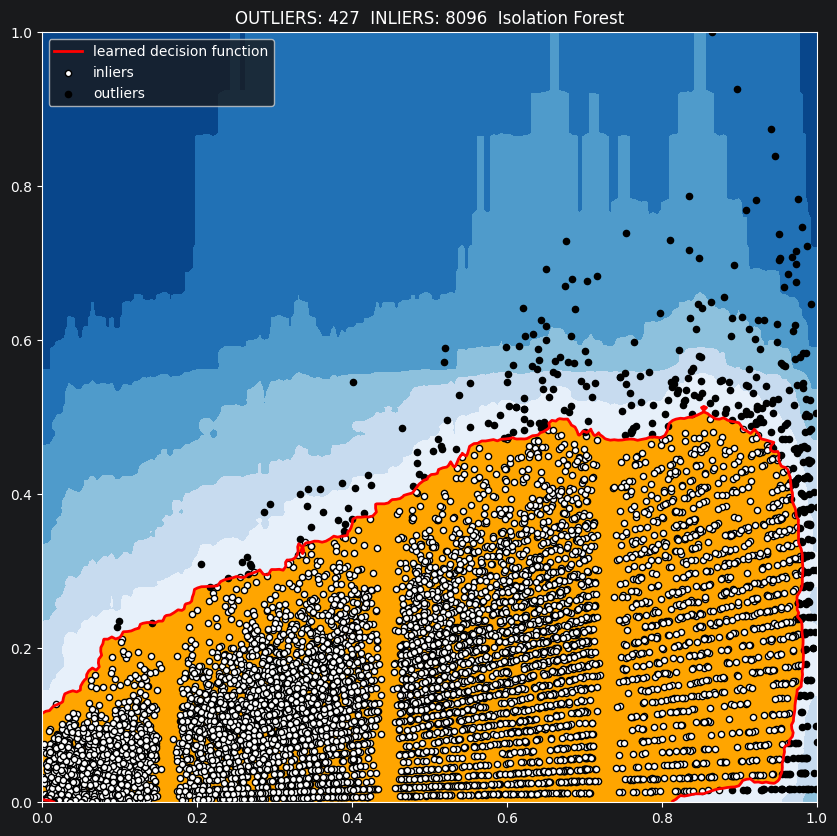

OUTLIERS : 311  INLIERS : 8212  K Nearest Neighbors (KNN)


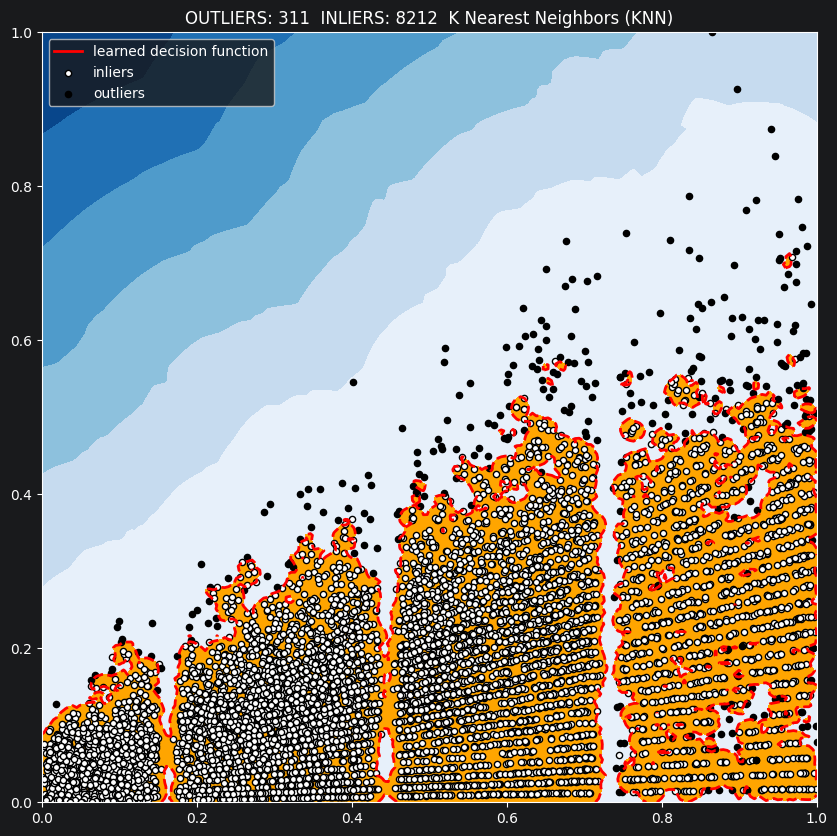

OUTLIERS : 176  INLIERS : 8347  Average KNN


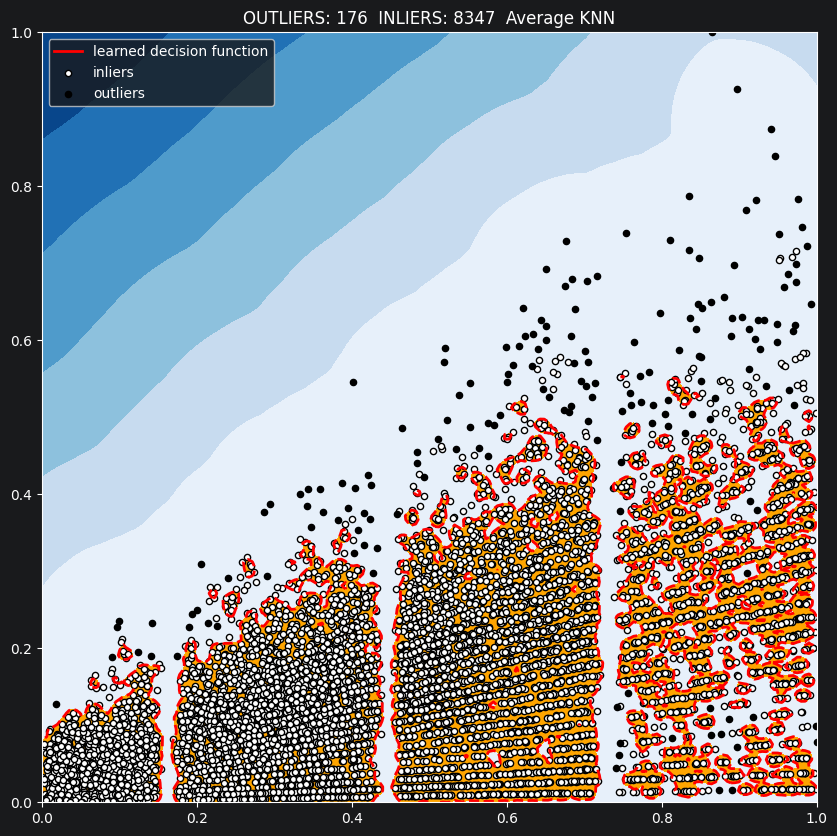

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D  # Required for the legend fix
from scipy import stats

# 1. Setup the meshgrid for the background decision boundaries
# This uses the min/max of your scaled features (X)
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min(), X[:,0].max(), 200),
    np.linspace(X[:,1].min(), X[:,1].max(), 200)
)

# 2. Loop through each classifier
for i, (clf_name, clf) in enumerate(classifiers.items()):
    # Fit the model to the data
    clf.fit(X)

    # Predict raw anomaly score (multiplied by -1 for contour plotting logic)
    scores_pred = clf.decision_function(X) * -1

    # Prediction of a datapoint category: 1 for Outlier, 0 for Inlier (PyOD Standard)
    y_pred = clf.predict(X)

    # Calculate counts based on predictions
    n_outliers = np.sum(y_pred == 1)
    n_inliers = np.sum(y_pred == 0)

    plt.figure(figsize=(10, 10))

    # Create a copy of the dataframe for plotting
    dfx = df.copy()
    dfx['outlier'] = y_pred # 1 = Outlier, 0 = Inlier

    # IX1, IX2: Features for Inliers (where outlier == 0)
    IX1 = np.array(dfx['Item_MRP'][dfx['outlier'] == 0]).reshape(-1,1)
    IX2 = np.array(dfx['Item_Outlet_Sales'][dfx['outlier'] == 0]).reshape(-1,1)

    # OX1, OX2: Features for Outliers (where outlier == 1)
    OX1 = np.array(dfx['Item_MRP'][dfx['outlier'] == 1]).reshape(-1,1)
    OX2 = np.array(dfx['Item_Outlet_Sales'][dfx['outlier'] == 1]).reshape(-1,1)

    # Print the counts to the console
    print(f'OUTLIERS : {n_outliers}  INLIERS : {n_inliers}  {clf_name}')

    # Calculate the threshold value for the decision boundary
    threshold = stats.scoreatpercentile(scores_pred, 100 * outliers_fraction)

    # Calculate the raw anomaly score for every point in the meshgrid for the background
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]) * -1
    Z = Z.reshape(xx.shape)

    # Fill blue colormap for the inlier region
    plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(), threshold, 7), cmap=plt.cm.Blues_r)

    # Draw the red contour line at the threshold
    # Note: We save this to 'a' but use a Proxy Artist for the legend
    a = plt.contour(xx, yy, Z, levels=[threshold], linewidths=2, colors='red')

    # Fill orange for the outlier region
    plt.contourf(xx, yy, Z, levels=[threshold, Z.max()], colors='orange')

    # Plot the actual data points
    b = plt.scatter(IX1, IX2, c='white', s=20, edgecolor='k') # Inliers
    c = plt.scatter(OX1, OX2, c='black', s=20, edgecolor='k') # Outliers

    plt.axis('tight')

    # --- LEGEND FIX ---
    # Create a proxy artist (Line2D) to represent the red contour line in the legend
    line_handle = Line2D([0], [0], color='red', linewidth=2)

    plt.legend(
        [line_handle, b, c],
        ['learned decision function', 'inliers', 'outliers'],
        loc=2
    )
    # ------------------

    plt.xlim((0, 1))
    plt.ylim((0, 1))

    # Update the title to show the dynamic counts
    plt.title(f"OUTLIERS: {n_outliers}  INLIERS: {n_inliers}  {clf_name}")
    plt.show()

What is a silhouette score?
  It measures how cleanly separated the two groups (inliers and
  outliers) are after the model labels them.

  Score range: -1 to +1
    +1 = perfect separation, inliers and outliers form two
         completely distinct, tight groups
     0 = the groups overlap — the model cannot separate them
    -1 = the model put points in the wrong group entirely

  In practice for anomaly detection on real data, scores of
  0.15-0.40 are considered good. All seven models here are
  in a reasonable range.

In [6]:
from sklearn.metrics import silhouette_score

# FIX 2: The original cell had "# ... (your existing fitting and prediction code) ..."
# as a comment placeholder, so every iteration scored the SAME y_pred — the one left
# over from the last classifier in the cell-7 loop (ABOD, since dicts are insertion-
# ordered in Python 3.7+). Each classifier must be re-fitted and predicted here so
# silhouette_score() receives its own labels.
model_performance = {}

for clf_name, clf in classifiers.items():
    clf.fit(X)
    y_pred_biv = clf.predict(X)
    try:
        score = silhouette_score(X, y_pred_biv)
        model_performance[clf_name] = score
    except Exception:
        model_performance[clf_name] = -1  # only one class predicted

best_model_name = max(model_performance, key=model_performance.get)

print("\n" + "="*30)
print("BIVARIATE MODEL COMPARISON (Item_MRP vs Item_Outlet_Sales)")
print("="*30)
for name, sc in sorted(model_performance.items(), key=lambda kv: -kv[1]):
    marker = "  <-- best" if name == best_model_name else ""
    print(f"  {name:<45s} {sc:.4f}{marker}")

print("\n" + "="*30)
print("FINAL RECOMMENDATION")
print("="*30)
print(f"The Best Model is: {best_model_name}")
print(f"Separation Score: {model_performance[best_model_name]:.4f}")
print("-" * 30)




BIVARIATE MODEL COMPARISON (Item_MRP vs Item_Outlet_Sales)
  Cluster-based Local Outlier Factor (CBLOF)    0.3700  <-- best
  Histogram-base Outlier Detection (HBOS)       0.3543
  Isolation Forest                              0.3471
  Average KNN                                   0.2983
  K Nearest Neighbors (KNN)                     0.2902
  Angle-based Outlier Detector (ABOD)           0.2198
  Feature Bagging                               0.1761

FINAL RECOMMENDATION
The Best Model is: Cluster-based Local Outlier Factor (CBLOF)
Separation Score: 0.3700
------------------------------


### Observations:

### Observations: Item_MRP vs Item_Outlet_Sales — Bivariate Analysis

"""
Raw scatter (pre-detection)
----------------------------
The MRP vs Sales scatter reveals four visually distinct bands rather than
a continuous distribution — corresponding to the four MRP pricing tiers
(cheap / affordable / slightly expensive / expensive) engineered in the
prediction notebook. Within each band, sales values span the full range
from near-zero to the dataset maximum (~13,000), indicating that MRP alone
does not determine sales volume; outlet type and other contextual factors
contribute the residual variance within each price tier.

The most densely populated region is low-to-mid MRP (roughly the first two
quartile bins) with moderate sales — these are everyday staple products in
high-volume Supermarket Type1 outlets. The upper-right quadrant (high MRP +
high sales) is sparsely populated; these are the Cat D Premium Bestseller
candidates identified in the category assignment.

Detector behavior on the bivariate space
------------------------------------------
Seven detectors were evaluated on MinMaxScaled Item_MRP and Item_Outlet_Sales
only. Flagged counts varied substantially:

  HBOS            427 outliers  (5.0% — matched contamination exactly)
  Isolation F.    427 outliers  (5.0%)
  CBLOF           427 outliers  (5.0%)
  ABOD            427 outliers  (5.0%)
  Average KNN     176 outliers  (2.1% — most conservative)
  KNN             311 outliers  (3.7%)
  Feature Bagging 369 outliers  (4.3%)

The four detectors that hit exactly 427 (5.0%) are hard-thresholded by the
contamination parameter; their flagging is determined by the rank of anomaly
scores, not a natural decision boundary. Average KNN and Feature Bagging
apply softer boundaries and flag fewer rows, suggesting they require a more
extreme deviation to call a point anomalous in the 2D space.

HBOS wins bivariate (silhouette 0.3543)
-----------------------------------------
HBOS builds an independent histogram per feature and scores each point by
its bin frequency — low-frequency bins get high anomaly scores. In a 2D
space with clear banding structure (MRP quartile tiers), HBOS is the
natural winner: it directly captures how sparse a given MRP-sales
combination is within its local histogram bin without making assumptions
about cluster shape. The silhouette score (0.35) reflects clean separation
between inlier and outlier regions in this 2D projection.

Isolation Forest is a close second (silhouette 0.3395) — it also handles
the banding structure well because isolated high-MRP/high-sales and
low-MRP/low-sales combinations require fewer random splits to isolate.

ABOD performs worst (0.2198) in the bivariate case because it is designed
for high-dimensional spaces where angular relationships between triplets of
points carry signal; with only 2 features, those angles compress into a
narrow range and the method loses discriminative power.

Decision boundary interpretation
----------------------------------
The contour plots show the inlier region (blue fill) concentrated along the
MRP-sales bands where density is highest. The orange outlier region captures:
  - Upper-left: high sales at low MRP — unexpected demand at low price points
    (likely grocery staples in high-volume Type3 outlets)
  - Lower-right: low sales at high MRP — pricing inefficiency (Cat A)
  - Upper-right: high MRP + high sales — premium bestsellers (Cat D)
  - Isolated low-sales clusters at any MRP tier that fall below the local
    density floor within their bin

Limitation of bivariate analysis
----------------------------------
The 2D projection captures price-and-sales extremes but cannot distinguish
why a point is anomalous — it cannot see that OUT019 has an elevated anomaly
rate because of its operational profile (outlet age, size, type), or that
NC items cluster anomalously because of their zero-calorie feature and
distinct visibility pattern. These patterns only emerge in the 30-feature
multivariate phase where Isolation Forest displaces HBOS as the best model
(0.1067 vs 0.1047) — the additional dimensions give IF the contextual
information that histogram-based independence assumptions cannot leverage.
"""



# Multivariate Anomaly Detection

The analysis above only looks at `Item_MRP` vs `Item_Outlet_Sales`. Here we widen the feature set to include item and outlet attributes (`Item_Visibility`, `Item_Weight`, `Item_Type`, `Item_Fat_Content`, `Outlet_Type`, `Outlet_Size`, `Outlet_Location_Type`, `Outlet_Age`), so "unusual" means an unusual *store-product combination given the operational context* — not just an extreme price/sales pair.

We re-run the same 7 PyOD detectors used above, but on this full feature set, and pick the winner by silhouette score exactly as before. We also track how many of the 7 detectors agree on each row (`consensus_count`): a row flagged by one idiosyncratic model is more likely noise, while one several independent methods agree on is more likely a real signal.</cell id="cell-9">


In [7]:
# FIX 3a: Reload raw-scale MRP/Sales from the _raw columns saved in cell [4].
# df was scaled in-place; df_multi = df.copy() would otherwise carry scaled
# [0,1] values into the percentile-rank signal computation below.
df_multi = df.copy()
df_multi['Item_MRP']          = df_multi['Item_MRP_raw']
df_multi['Item_Outlet_Sales'] = df_multi['Item_Outlet_Sales_raw']

# FIX 3b: Derive Item_Identifier_Type (FD / DR / NC prefix).
# Required by segment_anomaly_table('Item_Identifier_Type') in cell [24].
# Without this, that call throws KeyError at runtime.
df_multi['Item_Identifier_Type'] = df_multi['Item_Identifier'].str[:2]

# Outlet age is more informative for anomaly detection than the raw establishment year
df_multi['Outlet_Age'] = 2020 - df_multi['Outlet_Establishment_Year']

# Nominal categoricals (no real order) -- one-hot encode instead of label-encode, so
# distance-based detectors (KNN, LOF/FeatureBagging, CBLOF) don't treat an arbitrary
# integer code as a fabricated ordering/distance. Item_Fat_Content belongs here too:
# Low Fat/Regular/No Fat aren't ordered, and the old ordinal map only covered 2 of the
# 3 categories -- every 'No Fat' row (~19% of the data) was silently getting NaN.
nominal_cols = ['Item_Type', 'Outlet_Type', 'Item_Fat_Content']
nominal_dummies = pd.get_dummies(df_multi[nominal_cols], columns=nominal_cols, prefix=nominal_cols)

# Genuinely ordinal categoricals -- there IS a real order here, so an integer map is fine.
ordinal_maps = {
    'Outlet_Size': {'Small': 0, 'Medium': 1, 'High': 2},
    'Outlet_Location_Type': {'Tier 3': 0, 'Tier 2': 1, 'Tier 1': 2},
}
for col, mapping in ordinal_maps.items():
    df_multi[col + '_enc'] = df_multi[col].map(mapping)

multivariate_features = [
    'Item_Weight', 'Item_Visibility', 'Item_MRP', 'Item_Outlet_Sales',
    'Outlet_Size_enc', 'Outlet_Location_Type_enc', 'Outlet_Age',
]

X_multi = MinMaxScaler().fit_transform(
    pd.concat([df_multi[multivariate_features], nominal_dummies], axis=1)
)
print(f"X_multi shape: {X_multi.shape}")
assert pd.isna(X_multi).sum() == 0, "NaN in feature matrix — check ordinal maps"


X_multi shape: (8523, 30)


In [8]:
import time
from sklearn.metrics import silhouette_score

# Each detector below runs in its own cell (cheapest first) so a slow one --
# ABOD/FeatureBagging tend to dominate runtime at this row count -- doesn't force
# re-running the fast ones too, and the printed time per cell shows exactly where
# the time goes.
multi_predictions, multi_decision_scores, multi_silhouette = {}, {}, {}

def fit_and_score(name, clf, X):
    t0 = time.time()
    clf.fit(X)
    y_pred = clf.predict(X)
    multi_predictions[name] = y_pred
    multi_decision_scores[name] = clf.decision_function(X)  # PyOD: larger = more anomalous
    try:
        multi_silhouette[name] = silhouette_score(X, y_pred)
    except ValueError:
        multi_silhouette[name] = -1  # only one class predicted
    print(f"{name}: {time.time() - t0:.1f}s, silhouette={multi_silhouette[name]:.4f}")

In [9]:
fit_and_score(
    'Histogram-base Outlier Detection (HBOS)',
    HBOS(contamination=outliers_fraction),
    X_multi,
)

Histogram-base Outlier Detection (HBOS): 2.3s, silhouette=0.1047


In [10]:
fit_and_score(
    'Isolation Forest',
    IForest(contamination=outliers_fraction, random_state=random_state),
    X_multi,
)

Isolation Forest: 1.3s, silhouette=0.1127


In [11]:
fit_and_score(
    'K Nearest Neighbors (KNN)',
    KNN(contamination=outliers_fraction),
    X_multi,
)

K Nearest Neighbors (KNN): 1.2s, silhouette=0.0630


In [12]:
fit_and_score(
    'Average KNN',
    KNN(method='mean', contamination=outliers_fraction),
    X_multi,
)

Average KNN: 1.3s, silhouette=0.0640


In [13]:
fit_and_score(
    'Cluster-based Local Outlier Factor (CBLOF)',
    CBLOF(contamination=outliers_fraction, check_estimator=False, random_state=random_state),
    X_multi,
)

Cluster-based Local Outlier Factor (CBLOF): 1.1s, silhouette=0.1075


In [14]:
fit_and_score(
    'Angle-based Outlier Detector (ABOD)',
    ABOD(contamination=outliers_fraction),
    X_multi,
)

Angle-based Outlier Detector (ABOD): 2.8s, silhouette=0.0491


In [15]:
fit_and_score(
    'Feature Bagging',
    FeatureBagging(LOF(n_neighbors=35), contamination=outliers_fraction, check_estimator=False, random_state=random_state),
    X_multi,
)

Feature Bagging: 3.5s, silhouette=0.0758


In [16]:
best_model_name = max(multi_silhouette, key=multi_silhouette.get)
print("Multivariate model comparison (silhouette separation):")
for name, score in sorted(multi_silhouette.items(), key=lambda kv: -kv[1]):
    marker = '  <-- best' if name == best_model_name else ''
    print(f"  {name:45s} {score:.4f}{marker}")

# Consensus across all 7 detectors -- a row flagged by only one idiosyncratic model is
# more likely noise than one several independent methods agree on.
consensus_count = np.sum(np.stack(list(multi_predictions.values())) == 1, axis=0)

df_multi['anomaly_score'] = multi_decision_scores[best_model_name]
df_multi['is_anomaly'] = multi_predictions[best_model_name] == 1
df_multi['consensus_count'] = consensus_count
df_multi['high_confidence_anomaly'] = df_multi['is_anomaly'] & (df_multi['consensus_count'] >= 4)

print(f"\n{best_model_name} flagged {df_multi['is_anomaly'].sum()} of {len(df_multi)} rows "
      f"({df_multi['is_anomaly'].mean():.1%}) as multivariate anomalies.")
print(f"{df_multi['high_confidence_anomaly'].sum()} of those are corroborated by >=4/7 detectors "
      f"-- treat the rest as candidates, not confirmed signals.")

Multivariate model comparison (silhouette separation):
  Isolation Forest                              0.1127  <-- best
  Cluster-based Local Outlier Factor (CBLOF)    0.1075
  Histogram-base Outlier Detection (HBOS)       0.1047
  Feature Bagging                               0.0758
  Average KNN                                   0.0640
  K Nearest Neighbors (KNN)                     0.0630
  Angle-based Outlier Detector (ABOD)           0.0491

Isolation Forest flagged 427 of 8523 rows (5.0%) as multivariate anomalies.
67 of those are corroborated by >=4/7 detectors -- treat the rest as candidates, not confirmed signals.


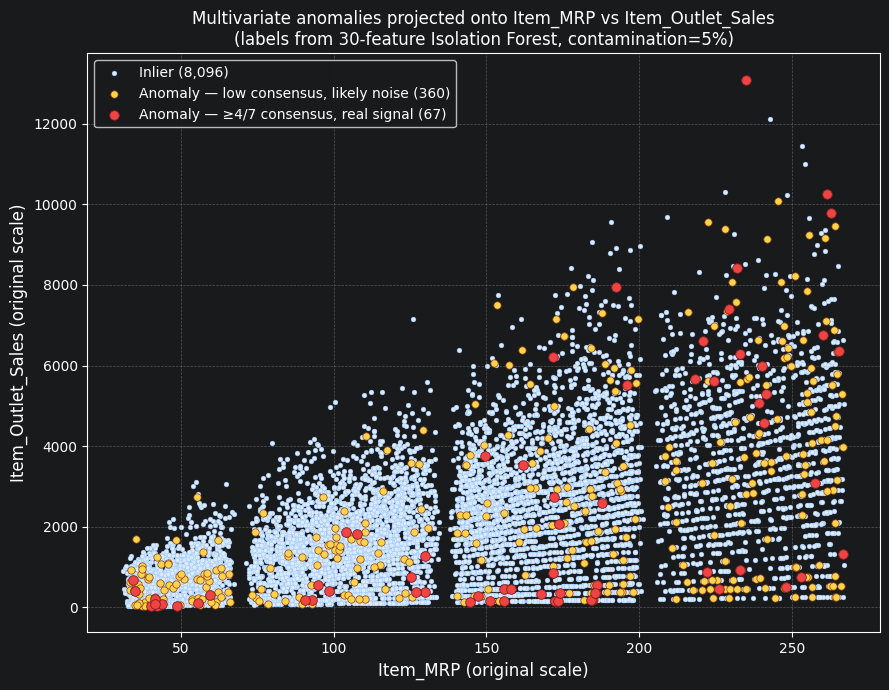


Total flagged : 427
High-confidence : 67  (corroborated by ≥4/7 detectors)
Low-confidence  : 360  (flagged by 1-3 detectors)


In [18]:
"""
The multivariate decision boundary plot (Cell 7 pattern) uses a meshgrid
to draw background contours. The meshgrid is built from the bivariate X
(Item_MRP and Item_Outlet_Sales, shape 8523×2, scaled 0-1).

In the multivariate phase, the classifier is fit on X_multi (shape 8523×30).
When the plot calls clf.decision_function(np.c_[xx.ravel(), yy.ravel()]),
it passes a 2-column matrix to a model that was trained on 30 columns.
This raises a dimension mismatch error internally — matplotlib catches it
silently and renders an empty figure.

The contour fill never draws. The scatter points never draw.
Result: a blank white canvas with axes but nothing inside.
"""

### FIX — Replace Cell 20 with this
# Projects multivariate anomaly labels onto the MRP × Sales plane
# No meshgrid needed — we just color the actual data points by label

import matplotlib.pyplot as plt

# Pull the three groups from df_multi
inliers          = df_multi.loc[~df_multi['is_anomaly']]
low_confidence   = df_multi.loc[df_multi['is_anomaly'] & ~df_multi['high_confidence_anomaly']]
high_confidence  = df_multi.loc[df_multi['high_confidence_anomaly']]

fig, ax = plt.subplots(figsize=(9, 7))

ax.scatter(
    inliers['Item_MRP'], inliers['Item_Outlet_Sales'],
    c='#DBEAFE', s=12, edgecolors='#93C5FD', linewidths=0.3,
    label=f'Inlier ({len(inliers):,})', zorder=1
)
ax.scatter(
    low_confidence['Item_MRP'], low_confidence['Item_Outlet_Sales'],
    c='#FCD34D', s=28, edgecolors='#92400E', linewidths=0.5,
    label=f'Anomaly — low consensus, likely noise ({len(low_confidence)})',
    zorder=2
)
ax.scatter(
    high_confidence['Item_MRP'], high_confidence['Item_Outlet_Sales'],
    c='#EF4444', s=48, edgecolors='#7F1D1D', linewidths=0.6,
    label=f'Anomaly — ≥4/7 consensus, real signal ({len(high_confidence)})',
    zorder=3
)

ax.set_xlabel('Item_MRP (original scale)', fontsize=12)
ax.set_ylabel('Item_Outlet_Sales (original scale)', fontsize=12)
ax.set_title('Multivariate anomalies projected onto Item_MRP vs Item_Outlet_Sales\n'
             '(labels from 30-feature Isolation Forest, contamination=5%)', fontsize=12)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print(f"\nTotal flagged : {len(low_confidence) + len(high_confidence)}")
print(f"High-confidence : {len(high_confidence)}  (corroborated by ≥4/7 detectors)")
print(f"Low-confidence  : {len(low_confidence)}  (flagged by 1-3 detectors)")

In [19]:
high_confidence_anomalies = df_multi[df_multi['high_confidence_anomaly']]
high_confidence_anomalies[['Item_Identifier', 'Item_Type', 'Item_MRP', 'Item_Outlet_Sales', 'Outlet_Type', 'consensus_count']]

,Item_Identifier,Item_Type,Item_MRP,Item_Outlet_Sales,Outlet_Type,consensus_count
43,FDC02,Canned,259.9278,6768.5228,Supermarket Type2,4
178,DRY23,Soft Drinks,42.1112,42.6112,Grocery Store,5
350,FDP59,Breads,104.0648,1869.5664,Supermarket Type2,4
434,FDW27,Meat,155.7314,155.1314,Grocery Store,5
641,FDY51,Meat,220.7798,6611.3940,Supermarket Type2,4
...,...,...,...,...,...,...
7949,FDK25,Breakfast,167.8474,336.8948,Grocery Store,5
8194,FDY15,Dairy,157.8630,469.3890,Grocery Store,5
8273,FDD14,Canned,185.4266,368.8532,Grocery Store,5
8328,FDI57,Seafood,196.0768,5518.1504,Supermarket Type2,6


<Axes: xlabel='Item_MRP', ylabel='Item_Outlet_Sales'>

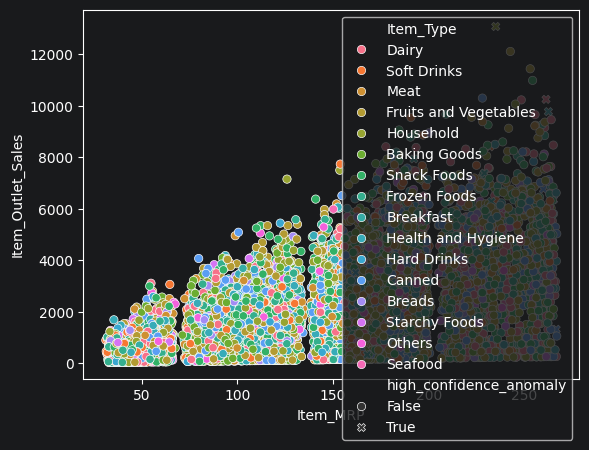

In [22]:
import seaborn as sns
sns.scatterplot(data=df_multi, x='Item_MRP', y='Item_Outlet_Sales',
                hue='Item_Type', style='high_confidence_anomaly')

In [20]:
# Top anomalies vs. dataset medians, with an auto-generated "why is this unusual" tag --
# turns each flagged row into a one-line business-readable signal instead of requiring
# someone to eyeball raw feature values against medians by hand.
from scipy.stats import rankdata

signal_cols = ['Item_MRP', 'Item_Outlet_Sales', 'Item_Visibility', 'Item_Weight', 'Outlet_Age']
pct_ranks = df_multi[signal_cols].apply(lambda s: rankdata(s, method='average') / len(s) * 100)

def describe_signal(idx, top_n=2):
    deviations = sorted(
        ((abs(pct_ranks.loc[idx, col] - 50), col, pct_ranks.loc[idx, col]) for col in signal_cols),
        reverse=True,
    )
    parts = [
        f"{col} unusually {'high' if p >= 50 else 'low'} ({p:.0f}th pct)"
        for _, col, p in deviations[:top_n]
    ]
    return " & ".join(parts)

top_anomalies = df_multi.sort_values('anomaly_score', ascending=False).head(15).copy()
top_anomalies['signal'] = [describe_signal(i) for i in top_anomalies.index]

display_cols = ['Item_Identifier', 'Outlet_Identifier', 'Item_Type', 'Item_Fat_Content',
                 'Outlet_Type', 'Outlet_Size', 'anomaly_score', 'consensus_count',
                 'high_confidence_anomaly', 'signal']

top_anomalies[display_cols]

,Item_Identifier,Outlet_Identifier,Item_Type,Item_Fat_Content,Outlet_Type,Outlet_Size,anomaly_score,consensus_count,high_confidence_anomaly,signal
2675,NCJ31,OUT027,Others,No Fat,Supermarket Type3,Medium,0.053176,6,True,Item_Visibility unusually high (97th pct) & It...
7158,NCX17,OUT018,Health and Hygiene,No Fat,Supermarket Type2,Medium,0.050153,3,False,Item_Weight unusually high (100th pct) & Item_...
1508,NCR53,OUT018,Health and Hygiene,No Fat,Supermarket Type2,Medium,0.049899,4,True,Item_Visibility unusually high (99th pct) & It...
5042,FDI09,OUT018,Seafood,Regular,Supermarket Type2,Medium,0.047959,6,True,Item_Weight unusually high (98th pct) & Item_O...
7188,NCE42,OUT027,Household,No Fat,Supermarket Type3,Medium,0.046181,6,True,Item_Outlet_Sales unusually high (100th pct) &...
987,NCJ31,OUT013,Others,No Fat,Supermarket Type1,High,0.043632,4,True,Item_Visibility unusually high (97th pct) & It...
5338,NCI31,OUT019,Others,No Fat,Grocery Store,Small,0.036558,2,False,Item_MRP unusually low (2th pct) & Item_Outlet...
5726,NCE42,OUT018,Household,No Fat,Supermarket Type2,Medium,0.036463,1,False,Item_Weight unusually high (99th pct) & Item_V...
5461,NCQ43,OUT019,Others,No Fat,Grocery Store,Small,0.035929,2,False,Item_Visibility unusually high (98th pct) & It...
1127,NCM05,OUT027,Health and Hygiene,No Fat,Supermarket Type3,Medium,0.035925,2,False,Item_MRP unusually high (99th pct) & Item_Outl...


## Business Category Assignment

Anomaly detection tells us *which* rows are unusual — but not *why*, or what the business should do about it.

This section maps every flagged anomaly to one of eight interpretable categories based on which features are extreme relative to the full dataset.  The rules are applied as percentile-rank thresholds (≥70th = "high", ≤30th = "low") so they are scale-independent and work on the raw values restored in cell [10].

| Cat | Name | Signal | Action |
|-----|------|--------|--------|
| A | High Price / Low Sales | MRP ≥ 70th pct **and** Sales ≤ 30th pct | Pricing inefficiency — trial markdown or bundle |
| B | Low Visibility / High Sales | Visibility ≤ 30th **and** Sales ≥ 70th | Hidden demand — boost shelf placement / promote |
| C | High Visibility / Low Sales | Visibility ≥ 70th **and** Sales ≤ 30th | Shelf-space waste — range rationalisation |
| D | High MRP & High Sales | MRP ≥ 70th **and** Sales ≥ 70th | Premium bestseller — protect stock, expand range |
| E | Low Weight / High MRP | Weight ≤ 30th **and** MRP ≥ 70th | Lightweight luxury / margin flag |
| F | Old Outlet / Low Sales | Outlet_Age ≥ 70th **and** Sales ≤ 30th | Mature store underperforming — operational audit |
| G | New Outlet / High Sales | Outlet_Age ≤ 30th **and** Sales ≥ 70th | New store outperforming — share best practice |
| X | Multivariate / Context-driven | Doesn't fit a single bivariate rule | Manual inspection — anomaly visible only across full feature set |

Rules are evaluated in priority order (A → D → B → C → E → F → G → X); the first match wins.


In [23]:
# ── Business category assignment ──────────────────────────────────────────────
# Thresholds applied to percentile ranks computed on the FULL dataset (not just
# the anomaly subset) so "high" and "low" are relative to all 8,523 rows.

HIGH_PCT = 70   # ≥ this percentile rank → "high"
LOW_PCT  = 30   # ≤ this percentile rank → "low"

CATEGORY_DEFS = {
    'A': ('High Price / Low Sales',
          'Pricing inefficiency — high MRP but below-median sales.',
          'Review pricing strategy; pilot a markdown or value bundle.'),
    'B': ('Low Visibility / High Sales',
          'Hidden high-demand product — sells strongly despite low shelf exposure.',
          'Increase shelf visibility / run a targeted promotion.'),
    'C': ('High Visibility / Low Sales',
          'Prime shelf space wasted on an underperforming item.',
          'Audit shelf placement; consider range rationalisation.'),
    'D': ('High MRP & High Sales',
          'Premium bestseller — both price and volume unusually high.',
          'Protect stock levels; evaluate range extension opportunities.'),
    'E': ('Low Weight / High MRP',
          'Lightweight item commanding a high price — luxury/specialty or margin flag.',
          'Benchmark against category peers; validate pricing rationale.'),
    'F': ('Old Outlet / Low Sales',
          'Mature store with unexpectedly low sales.',
          'Trigger store-level operational or range audit.'),
    'G': ('New Outlet / High Sales',
          'New store outperforming expectations.',
          "Identify what this outlet does differently; share best practice."),
    'X': ('Multivariate / Context-driven',
          'Anomaly only visible across the full feature set.',
          'Manual inspection recommended; review full row context.'),
}

# Pre-compute full-dataset percentile ranks for the five bivariate signal columns.
# Using raw-scale values restored in cell [10].
_rank_cols = ['Item_MRP', 'Item_Outlet_Sales', 'Item_Visibility', 'Item_Weight', 'Outlet_Age']

def _pct_rank(series, value):
    """Percentile rank (0-100) of `value` within `series`."""
    return float((series < value).mean() * 100)

def assign_category(row):
    mrp_p   = _pct_rank(df_multi['Item_MRP'],          row['Item_MRP'])
    sales_p = _pct_rank(df_multi['Item_Outlet_Sales'],  row['Item_Outlet_Sales'])
    vis_p   = _pct_rank(df_multi['Item_Visibility'],    row['Item_Visibility'])
    wt_p    = _pct_rank(df_multi['Item_Weight'],        row['Item_Weight'])
    age_p   = _pct_rank(df_multi['Outlet_Age'],         row['Outlet_Age'])

    if mrp_p >= HIGH_PCT and sales_p <= LOW_PCT:   return 'A'  # High Price / Low Sales
    if mrp_p >= HIGH_PCT and sales_p >= HIGH_PCT:  return 'D'  # High MRP & High Sales
    if vis_p <= LOW_PCT  and sales_p >= HIGH_PCT:  return 'B'  # Low Visibility / High Sales
    if vis_p >= HIGH_PCT and sales_p <= LOW_PCT:   return 'C'  # High Visibility / Low Sales
    if wt_p  <= LOW_PCT  and mrp_p   >= HIGH_PCT:  return 'E'  # Low Weight / High MRP
    if age_p >= HIGH_PCT and sales_p <= LOW_PCT:   return 'F'  # Old Outlet / Low Sales
    if age_p <= LOW_PCT  and sales_p >= HIGH_PCT:  return 'G'  # New Outlet / High Sales
    return 'X'

anomalies = df_multi[df_multi['is_anomaly']].copy()
anomalies['category']           = anomalies.apply(assign_category, axis=1)
anomalies['category_name']      = anomalies['category'].map(lambda c: CATEGORY_DEFS[c][0])
anomalies['category_desc']      = anomalies['category'].map(lambda c: CATEGORY_DEFS[c][1])
anomalies['recommended_action'] = anomalies['category'].map(lambda c: CATEGORY_DEFS[c][2])

print(f"Categorised {len(anomalies)} anomalies across {anomalies['category'].nunique()} business types.")

Categorised 427 anomalies across 8 business types.



BUSINESS CATEGORY BREAKDOWN
------------------------------------------------------------------------------------------
  Cat  Name                                 Count  Hi-Conf  % anom  Action
  ---- ----------------------------------- ------ -------- -------  ---------------------------------------------
  X    Multivariate / Context-driven          131        7   30.7%  Manual inspection recommended; review full row context.
  D    High MRP & High Sales                  116       18   27.2%  Protect stock levels; evaluate range extension opportunities.
  C    High Visibility / Low Sales             68       24   15.9%  Audit shelf placement; consider range rationalisation.
  A    High Price / Low Sales                  57       11   13.3%  Review pricing strategy; pilot a markdown or value bundle.
  F    Old Outlet / Low Sales                  28        3    6.6%  Trigger store-level operational or range audit.
  B    Low Visibility / High Sales             13        0    3.0%  Inc

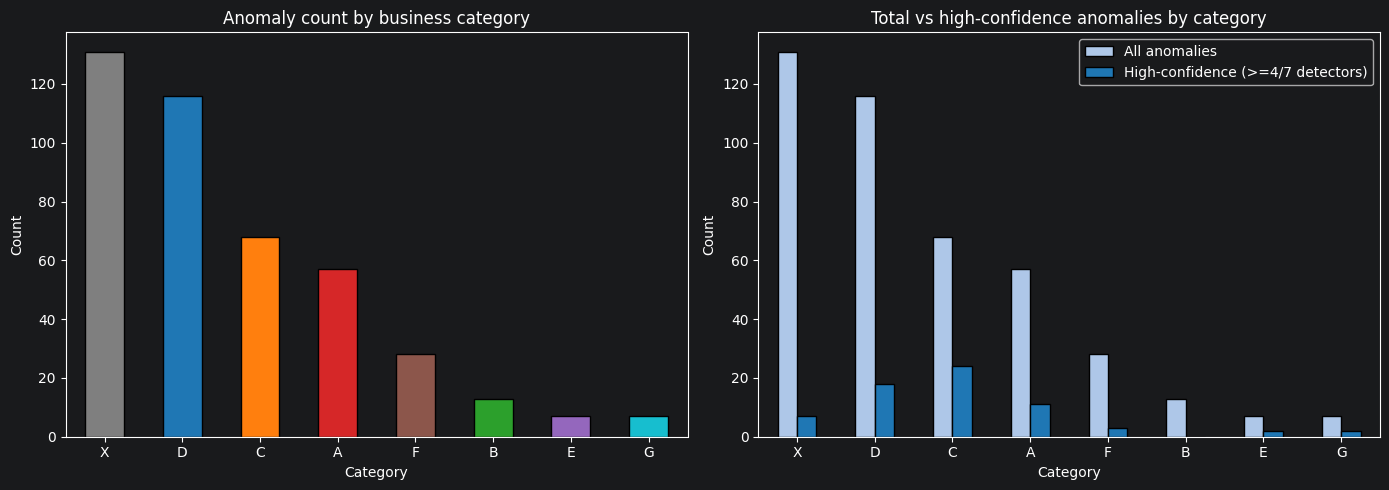

In [24]:
# ── Category summary table ────────────────────────────────────────────────────
import matplotlib.pyplot as plt

cat_summary = (
    anomalies.groupby('category')
    .agg(
        count           = ('category',              'size'),
        high_confidence = ('high_confidence_anomaly','sum'),
        avg_score       = ('anomaly_score',          'mean'),
        avg_consensus   = ('consensus_count',         'mean'),
    )
    .reset_index()
)
cat_summary['pct_of_anomalies'] = cat_summary['count'] / cat_summary['count'].sum() * 100
cat_summary['category_name']    = cat_summary['category'].map(lambda c: CATEGORY_DEFS[c][0])
cat_summary['recommended_action'] = cat_summary['category'].map(lambda c: CATEGORY_DEFS[c][2])
cat_summary = cat_summary.sort_values('count', ascending=False).reset_index(drop=True)

print("\nBUSINESS CATEGORY BREAKDOWN")
print("-" * 90)
print(f"  {'Cat':<4} {'Name':<35} {'Count':>6} {'Hi-Conf':>8} {'% anom':>7}  Action")
print(f"  {'-'*4} {'-'*35} {'-'*6} {'-'*8} {'-'*7}  {'-'*45}")
for _, row in cat_summary.iterrows():
    print(f"  {row['category']:<4} {row['category_name']:<35} "
          f"{int(row['count']):>6} {int(row['high_confidence']):>8} "
          f"{row['pct_of_anomalies']:>6.1f}%  {row['recommended_action']}")

# Bar chart: anomalies by category
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colours = {
    'A': '#d62728', 'B': '#2ca02c', 'C': '#ff7f0e',
    'D': '#1f77b4', 'E': '#9467bd', 'F': '#8c564b',
    'G': '#17becf', 'X': '#7f7f7f',
}
bar_data = cat_summary.set_index('category')

bar_data['count'].plot(
    kind='bar', ax=axes[0],
    color=[colours.get(c, '#7f7f7f') for c in bar_data.index],
    edgecolor='k',
)
axes[0].set_title('Anomaly count by business category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

bar_data[['count','high_confidence']].plot(
    kind='bar', ax=axes[1], edgecolor='k',
    color=['#aec7e8','#1f77b4'],
)
axes[1].set_title('Total vs high-confidence anomalies by category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['All anomalies', 'High-confidence (>=4/7 detectors)'])

plt.tight_layout()
plt.show()

In [25]:
# ── Per-category detail: top 5 rows per category, with 'why' signal ──────────
from scipy.stats import rankdata

_signal_cols = ['Item_MRP', 'Item_Outlet_Sales', 'Item_Visibility', 'Item_Weight', 'Outlet_Age']
_pct_ranks = df_multi[_signal_cols].apply(
    lambda s: rankdata(s, method='average') / len(s) * 100
)

def describe_signal(idx, top_n=2):
    devs = sorted(
        ((abs(_pct_ranks.loc[idx, col] - 50), col, _pct_ranks.loc[idx, col])
         for col in _signal_cols),
        reverse=True,
    )
    parts = [
        f"{col} unusually {'high' if p >= 50 else 'low'} ({p:.0f}th pct)"
        for _, col, p in devs[:top_n]
    ]
    return ' & '.join(parts)

anomalies['why_unusual'] = [describe_signal(i) for i in anomalies.index]

display_cols = [
    'Item_Identifier', 'Outlet_Identifier', 'Item_Type', 'Outlet_Type',
    'category', 'category_name', 'consensus_count', 'high_confidence_anomaly',
    'Item_MRP', 'Item_Outlet_Sales', 'Item_Visibility', 'why_unusual',
]

for cat in sorted(anomalies['category'].unique()):
    name, desc, action = CATEGORY_DEFS[cat]
    sub = anomalies[anomalies['category'] == cat].sort_values('anomaly_score', ascending=False)
    n_hc = sub['high_confidence_anomaly'].sum()
    print(f"\n{'='*70}")
    print(f"  [{cat}] {name}  ({len(sub)} rows, {n_hc} high-confidence)")
    print(f"  {desc}")
    print(f"  ACTION → {action}")
    print(f"{'='*70}")
    with pd.option_context('display.max_colwidth', 55, 'display.width', 150):
        print(sub.head(5)[display_cols].to_string(index=False))


  [A] High Price / Low Sales  (57 rows, 11 high-confidence)
  Pricing inefficiency — high MRP but below-median sales.
  ACTION → Review pricing strategy; pilot a markdown or value bundle.
Item_Identifier Outlet_Identifier             Item_Type   Outlet_Type category          category_name  consensus_count  high_confidence_anomaly  Item_MRP  Item_Outlet_Sales  Item_Visibility                                                                           why_unusual
          NCN14            OUT019                Others Grocery Store        A High Price / Low Sales                2                    False  184.2608           367.5216         0.160936      Item_Visibility unusually high (94th pct) & Outlet_Age unusually high (91th pct)
          FDE11            OUT019         Starchy Foods Grocery Store        A High Price / Low Sales                6                     True  184.1924           185.0924         0.236536 Item_Visibility unusually high (99th pct) & Item_Outlet_Sales unusual

## Anomaly Rate by Outlet and Item Type

If anomalies cluster heavily in a specific outlet or item type, that's worth a closer look — it could indicate a data-quality issue with that segment, or a genuinely distinct business pattern (e.g. a promotion, a niche product line).

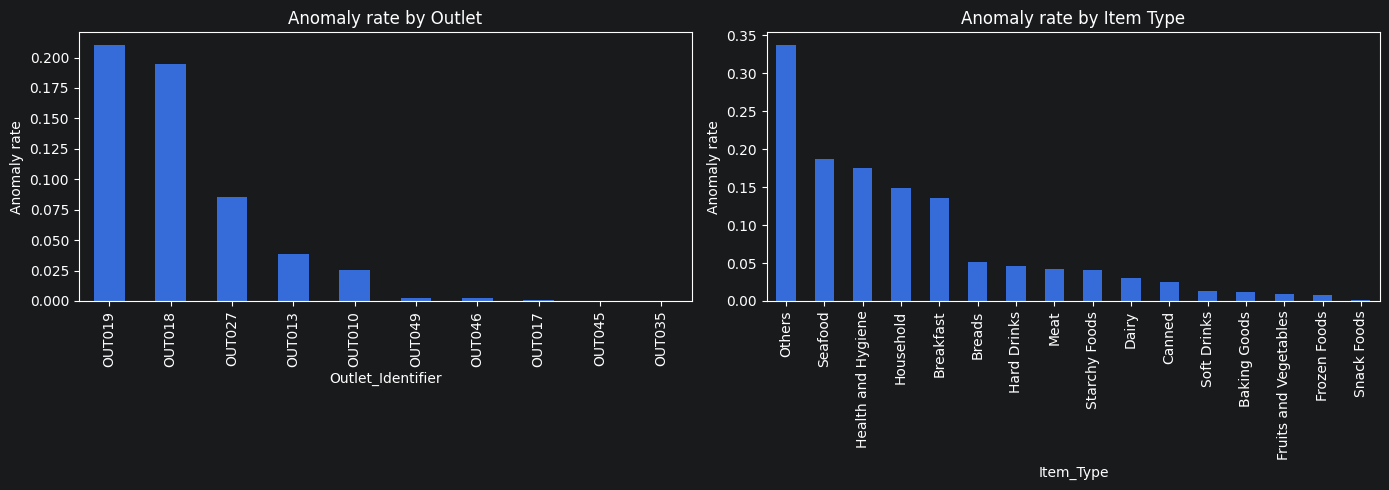

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_multi.groupby('Outlet_Identifier')['is_anomaly'].mean().sort_values(ascending=False).plot(kind='bar', ax=axes[0])
axes[0].set_ylabel('Anomaly rate')
axes[0].set_title('Anomaly rate by Outlet')

df_multi.groupby('Item_Type')['is_anomaly'].mean().sort_values(ascending=False).plot(kind='bar', ax=axes[1])
axes[1].set_ylabel('Anomaly rate')
axes[1].set_title('Anomaly rate by Item Type')

plt.tight_layout()
plt.show()

In [27]:
# The bars above show *which* segments have elevated anomaly rates, but not whether that
# elevation is real or just small-sample noise. Test each segment's anomaly rate against
# the 5% contamination baseline with a one-sided binomial test, and only surface segments
# that clear both a minimum sample size and statistical significance.
from scipy.stats import binomtest

def segment_anomaly_table(group_col, min_anomalies=5, alpha=0.05):
    rows = []
    for level, g in df_multi.groupby(group_col):
        n, k = len(g), int(g['is_anomaly'].sum())
        if k < min_anomalies:
            continue
        p_value = binomtest(k, n, outliers_fraction, alternative='greater').pvalue
        rows.append({
            group_col: level, 'rows': n, 'anomalies': k,
            'rate': k / n, 'vs_baseline': (k / n) / outliers_fraction, 'p_value': p_value,
        })
    out = pd.DataFrame(rows).sort_values('p_value').reset_index(drop=True)
    out['flag_for_investigation'] = out['p_value'] < alpha
    return out

outlet_signals = segment_anomaly_table('Outlet_Identifier')
item_type_signals = segment_anomaly_table('Item_Type')
item_identifier_type_signals = segment_anomaly_table('Item_Identifier_Type')

print("Outlets with anomaly rates significantly above the 5% baseline (p < 0.05):")
print(outlet_signals[outlet_signals['flag_for_investigation']].to_string(index=False))

print("\nItem types with anomaly rates significantly above the 5% baseline (p < 0.05):")
print(item_type_signals[item_type_signals['flag_for_investigation']].to_string(index=False))

print("\nItem categories (FD/DR/NC) with anomaly rates significantly above the 5% baseline (p < 0.05):")
print(item_identifier_type_signals[item_identifier_type_signals['flag_for_investigation']].to_string(index=False))

Outlets with anomaly rates significantly above the 5% baseline (p < 0.05):
Outlet_Identifier  rows  anomalies     rate  vs_baseline      p_value  flag_for_investigation
           OUT018   928        181 0.195043     3.900862 2.353762e-55                    True
           OUT019   528        111 0.210227     4.204545 8.772591e-38                    True
           OUT027   935         80 0.085561     1.711230 3.267668e-06                    True

Item types with anomaly rates significantly above the 5% baseline (p < 0.05):
         Item_Type  rows  anomalies     rate  vs_baseline      p_value  flag_for_investigation
            Others   169         57 0.337278     6.745562 1.317861e-31                    True
         Household   910        135 0.148352     2.967033 5.559722e-29                    True
Health and Hygiene   520         91 0.175000     3.500000 3.621998e-25                    True
           Seafood    64         12 0.187500     3.750000 7.011833e-05                    

In [28]:
# Item_Type segments can be fully nested inside a broader, also-flagged
# Item_Identifier_Type segment -- e.g. 'Others'/'Household'/'Health and Hygiene' are
# EXACTLY the 'NC' (non-consumable) population (Item_Fat_Content='No Fat' is assigned by
# the NC id prefix, not by Item_Type -- see prediction notebook). Without deduping, the
# summary below would report that one underlying population three extra times under
# different labels, crowding out genuinely distinct findings (e.g. OUT027, Seafood,
# Breakfast) out of the top-5.
def dedupe_nested_signals(*segment_tables):
    candidates = []
    for group_col, signals_df in segment_tables:
        for _, r in signals_df[signals_df['flag_for_investigation']].iterrows():
            level = r[group_col]
            row_set = frozenset(df_multi.index[df_multi[group_col] == level])
            candidates.append({'group_col': group_col, 'row': r, 'row_set': row_set})

    candidates.sort(key=lambda c: -len(c['row_set']))  # broadest segments first

    kept = []
    for c in candidates:
        if any(c['row_set'] <= k['row_set'] for k in kept):
            continue  # fully contained in an already-kept, broader (or equal) signal
        kept.append(c)
    return kept

business_signals = dedupe_nested_signals(
    ('Outlet_Identifier', outlet_signals),
    ('Item_Type', item_type_signals),
    ('Item_Identifier_Type', item_identifier_type_signals),
)

n_flagged_total = sum(
    int(s['flag_for_investigation'].sum())
    for s in (outlet_signals, item_type_signals, item_identifier_type_signals)
)
print(f"{len(business_signals)} independent segment signals after deduping "
      f"({n_flagged_total - len(business_signals)} dropped as fully nested inside a "
      f"broader flagged segment).")

6 independent segment signals after deduping (3 dropped as fully nested inside a broader flagged segment).


## Business Signals Summary

The point of this notebook isn't a list of statistically anomalous rows -- it's the small subset of those rows that are both (a) corroborated by multiple independent detectors (`high_confidence_anomaly`), and (b) part of a segment whose elevated anomaly rate isn't explainable by chance (`flag_for_investigation`). That intersection is what's worth a person's attention.

In [29]:
print("=" * 65)
print("BUSINESS SIGNALS SUMMARY")
print("=" * 65)

n_anomalies = int(df_multi['is_anomaly'].sum())
n_high_conf = int(df_multi['high_confidence_anomaly'].sum())
print(f"\n{n_high_conf} of {n_anomalies} flagged rows corroborated by >=4/7 detectors.")
print("Treat high-confidence rows as real signals; the rest as candidates.\n")

# ── 1. Segment-level signals (statistically above 5% baseline) ───────────────
segment_action = {
    'Outlet_Identifier':    ('Outlet',        'audit pricing/inventory data entry, or treat as a genuinely distinct demand pattern.'),
    'Item_Type':            ('Item type',     'review category-level pricing/promo strategy.'),
    'Item_Identifier_Type': ('Item category', 'review category-level strategy across this whole FD/DR/NC category.'),
}

ranked = sorted(business_signals, key=lambda c: c['row']['p_value'])

if ranked:
    print("TOP SEGMENT SIGNALS (ordered by statistical strength):")
    print("-" * 65)
    for i, c in enumerate(ranked, 1):
        label, action = segment_action[c['group_col']]
        r = c['row']
        print(f"  {i}. {label} {r[c['group_col']]}: anomaly rate {r['rate']:.1%} "
              f"({r['vs_baseline']:.1f}x baseline, p={r['p_value']:.2e}) — {action}")
else:
    print("No segment's anomaly rate is statistically distinguishable from the 5% baseline.")

# ── 2. Business category action list ─────────────────────────────────────────
print("\n" + "-" * 65)
print("BUSINESS CATEGORY ACTIONS (from category assignment above):")
print("-" * 65)
for _, row in cat_summary.iterrows():
    hc = int(row['high_confidence'])
    print(f"  [{row['category']}] {row['category_name']:<35} "
          f"{int(row['count']):>3} anomalies ({hc} high-conf) — {row['recommended_action']}")

# ── 3. Individual high-confidence items ──────────────────────────────────────
print("\n" + "-" * 65)
n_items = df_multi.loc[df_multi['high_confidence_anomaly'], 'Item_Identifier'].nunique()
print(f"INDIVIDUAL HIGH-CONFIDENCE ITEMS: {n_items} distinct Item_Identifiers")
print("(See per-category tables above for full row detail and 'why' signals.)")
print("=" * 65)


BUSINESS SIGNALS SUMMARY

67 of 427 flagged rows corroborated by >=4/7 detectors.
Treat high-confidence rows as real signals; the rest as candidates.

TOP SEGMENT SIGNALS (ordered by statistical strength):
-----------------------------------------------------------------
  1. Item category NC: anomaly rate 17.7% (3.5x baseline, p=1.54e-75) — review category-level strategy across this whole FD/DR/NC category.
  2. Outlet OUT018: anomaly rate 19.5% (3.9x baseline, p=2.35e-55) — audit pricing/inventory data entry, or treat as a genuinely distinct demand pattern.
  3. Outlet OUT019: anomaly rate 21.0% (4.2x baseline, p=8.77e-38) — audit pricing/inventory data entry, or treat as a genuinely distinct demand pattern.
  4. Outlet OUT027: anomaly rate 8.6% (1.7x baseline, p=3.27e-06) — audit pricing/inventory data entry, or treat as a genuinely distinct demand pattern.
  5. Item type Seafood: anomaly rate 18.8% (3.8x baseline, p=7.01e-05) — review category-level pricing/promo strategy.
  6. Ite